In [ ]:
!pip install transformers pandas torch scikit-learn
!pip install nltk spacy word2number
!python -m spacy download en_core_web_sm
!pip install -U transformers

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=8424e37409da8be258cf466276d2e8a001a3531bb2fb158b773884af89013513
  Stored in directory: /root/.cache/pip/wheels/5b/79/fb/d25928e599c7e11fe4e00d32048cd74933f34a74c633d2aea6
Successfully built word2number
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,2.376468,0.127820,0.038548,0.127820,0.055237
2,2.443800,2.277402,0.176692,0.132913,0.176692,0.126333
3,2.334300,2.174177,0.323308,0.385064,0.323308,0.287767
4,2.167900,1.960912,0.473684,0.467709,0.473684,0.421880
5,2.167900,1.776457,0.537594,0.587914,0.537594,0.512318
6,1.927800,1.559431,0.654135,0.607257,0.654135,0.610569
7,1.650800,1.384555,0.669173,0.639305,0.669173,0.626834
8,1.416000,1.220426,0.736842,0.673726,0.736842,0.689190
9,1.228400,1.068535,0.763158,0.665108,0.763158,0.704904
10,1.228400,0.956106,0.770677,0.667137,0.770677,0.711015


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           A       0.88      0.94      0.91        32
           F       0.73      0.85      0.79        39
          FT       0.91      1.00      0.95        31
           L       0.86      1.00      0.93        31
          LF       0.94      0.91      0.93        35
          MN       0.94      1.00      0.97        30
           O       0.50      0.22      0.31         9
          PE       1.00      0.12      0.22         8
          SC       0.89      0.97      0.93        32
          SE       0.38      0.30      0.33        10
          US       0.75      0.30      0.43        10

    accuracy                           0.85       267
   macro avg       0.80      0.69      0.70       267
weighted avg       0.84      0.85      0.83       267



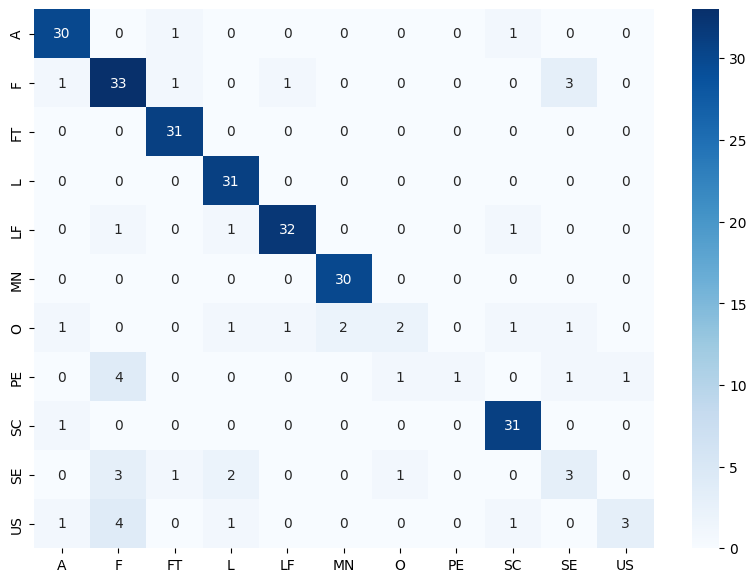

In [ ]:
# --- Imports ---
import os
import random
import re
import string
from nltk.corpus import stopwords, wordnet
import nltk
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from transformers import (
    BertTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    BertModel,
    TrainerCallback
)
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
os.environ["WANDB_DISABLED"] = "true"
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

# --- Text Processing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words and len(word) > 3]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def phrase_insertion(text, n=1):
    phrases = ["the system shall", "must be able to", "should ensure that"]
    words = text.split()
    for _ in range(n):
        add_phrase = random.choice(phrases)
        random_idx = random.randint(0, len(words)-1)
        words.insert(random_idx, add_phrase)
    return ' '.join(words)

def text_simplification(text):
    text = re.sub(r'\bthe system shall\b', '', text)
    text = re.sub(r'\bmust be able to\b', '', text)
    text = re.sub(r'\bshould ensure that\b', '', text)
    return text.strip()

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    return ' '.join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# --- Data Loading ---
DATA_PATH_CANDIDATES = [
    os.path.join('..', 'data', 'exp', 'promise_exp.csv'),
    os.path.join('data', 'exp', 'promise_exp.csv'),
    r'D:\semester4\SWR302\RBL_requirements_classification\rbl-requirements-classification\data\exp\promise_exp.csv',
]

for data_path in DATA_PATH_CANDIDATES:
    if os.path.exists(data_path):
        break
else:
    raise FileNotFoundError(
        "Could not find promise_exp.csv. Expected it under data/exp/promise_exp.csv."
    )

df = pd.read_csv(data_path)
print(f"Loaded PROMISE expanded dataset from: {data_path}")
df['cleaned_text'] = df['RequirementText'].apply(clean_text)
df = df[df['class'].map(df['class'].value_counts()) > 1]

# --- Augmentation ---
augmentation_targets = {'FT':200,'L':200,'MN':200,'A':200,'CS':200,'LF':200,'SC':200,'PO':200}
augmented = []

for cls, min_required in augmentation_targets.items():
    class_df = df[df['class'] == cls]
    needed = max(0, min_required - len(class_df))
    if len(class_df) == 0 or needed == 0:
        continue
    multiplier = needed // len(class_df) + 1
    for _, row in class_df.iterrows():
        for _ in range(multiplier):
            text = row['cleaned_text']
            aug_text = synonym_replacement(text, 1)
            aug_text = phrase_insertion(aug_text, 1)
            aug_text = text_simplification(aug_text)
            aug_text = random_swap(aug_text, 1)
            aug_text = random_deletion(aug_text, p=0.1)
            augmented.append({
                'RequirementText': row['RequirementText'],
                'cleaned_text': aug_text,
                'class': cls
            })

df_aug = pd.DataFrame(augmented)
df_combined = pd.concat([df, df_aug], ignore_index=True)

# --- Label Encoding & Split ---
texts = df_combined['cleaned_text'].tolist()
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df_combined['class'])

train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    val_test_texts, val_test_labels, test_size=0.5,
    stratify=val_test_labels, random_state=42
)

# --- Tokenization (BERT ONLY) ---
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(tokenizer, texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

bert_train_enc = tokenize(bert_tokenizer, train_texts)
bert_val_enc   = tokenize(bert_tokenizer, val_texts)
bert_test_enc  = tokenize(bert_tokenizer, test_texts)

# --- Dataset ---
class BertOnlyDataset(Dataset):
    def __init__(self, bert_enc, labels):
        self.bert = bert_enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.bert['input_ids'][idx]),
            'attention_mask': torch.tensor(self.bert['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = BertOnlyDataset(bert_train_enc, train_labels)
val_dataset   = BertOnlyDataset(bert_val_enc, val_labels)
test_dataset  = BertOnlyDataset(bert_test_enc, test_labels)

# --- Model ---
class BertOnlyClassifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = torch.nn.Dropout(0.5)
        self.classifier = torch.nn.Linear(768, num_labels, bias=False)

        for name, param in self.bert.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).pooler_output

        logits = self.classifier(self.dropout(output))
        loss = torch.nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

# --- Metrics ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# --- Accuracy Callback ---
class AccuracyPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_metrics = trainer.evaluate(train_dataset)
        val_metrics = trainer.evaluate(val_dataset)
        self.train_accuracies.append(train_metrics["eval_accuracy"])
        self.val_accuracies.append(val_metrics["eval_accuracy"])
        self.train_losses.append(train_metrics["eval_loss"])
        self.val_losses.append(val_metrics["eval_loss"])

accuracy_callback = AccuracyPlotCallback()

# --- Training ---
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.02,
    learning_rate=1e-5,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    fp16=True,
    report_to="none",
)

model = BertOnlyClassifier(num_labels=len(label_encoder.classes_))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), accuracy_callback]
)

trainer.train()

# --- Evaluation ---
test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.show()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.554500,2.486222,0.106017,0.032399,0.106017,0.039927
2,2.477700,2.365970,0.223496,0.106443,0.223496,0.118343
3,2.355100,2.205481,0.243553,0.336680,0.243553,0.145111
4,2.182900,1.971390,0.369628,0.418649,0.369628,0.287886
5,1.980400,1.751955,0.550143,0.527835,0.550143,0.487101
6,1.777700,1.534330,0.653295,0.582588,0.653295,0.602477
7,1.589200,1.352579,0.702006,0.670467,0.702006,0.652185
8,1.408100,1.185861,0.739255,0.690793,0.739255,0.683646
9,1.249200,1.058116,0.750716,0.703189,0.750716,0.694297
10,1.111900,0.945155,0.776504,0.721258,0.776504,0.718307


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           A       0.91      0.97      0.94        32
           F       0.87      0.94      0.91        66
          FT       0.84      0.97      0.90        33
           L       0.97      1.00      0.98        32
          LF       1.00      0.95      0.97        37
          MN       0.97      1.00      0.99        33
           O       1.00      0.17      0.29        12
          PE       0.83      0.50      0.62        10
          PO       0.86      1.00      0.92        30
          SC       0.97      1.00      0.99        33
          SE       0.76      0.68      0.72        19
          US       0.80      0.67      0.73        12

    accuracy                           0.91       349
   macro avg       0.90      0.82      0.83       349
weighted avg       0.91      0.91      0.89       349



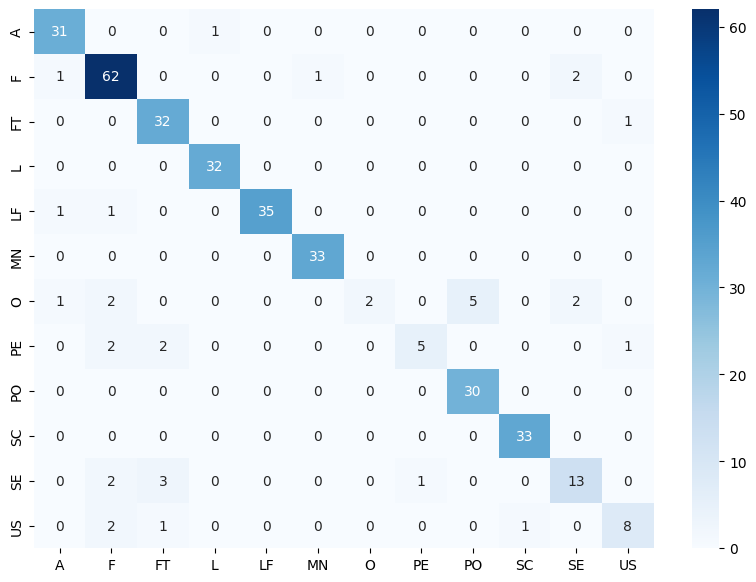

In [ ]:
# --- Imports ---
import os
import random
import re
import string
from nltk.corpus import stopwords, wordnet
import nltk
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from transformers import (
    BertTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    BertModel,
    TrainerCallback
)
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
os.environ["WANDB_DISABLED"] = "true"
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

# --- Text Processing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words and len(word) > 3]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def phrase_insertion(text, n=1):
    phrases = ["the system shall", "must be able to", "should ensure that"]
    words = text.split()
    for _ in range(n):
        add_phrase = random.choice(phrases)
        random_idx = random.randint(0, len(words)-1)
        words.insert(random_idx, add_phrase)
    return ' '.join(words)

def text_simplification(text):
    text = re.sub(r'\bthe system shall\b', '', text)
    text = re.sub(r'\bmust be able to\b', '', text)
    text = re.sub(r'\bshould ensure that\b', '', text)
    return text.strip()

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    return ' '.join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# --- Data Loading ---
DATA_PATH_CANDIDATES = [
    os.path.join('..', 'data', 'exp', 'promise_exp.csv'),
    os.path.join('data', 'exp', 'promise_exp.csv'),
    r'D:\semester4\SWR302\RBL_requirements_classification\rbl-requirements-classification\data\exp\promise_exp.csv',
]

for data_path in DATA_PATH_CANDIDATES:
    if os.path.exists(data_path):
        break
else:
    raise FileNotFoundError(
        "Could not find promise_exp.csv. Expected it under data/exp/promise_exp.csv."
    )

df = pd.read_csv(data_path)
print(f"Loaded PROMISE expanded dataset from: {data_path}")
df['cleaned_text'] = df['RequirementText'].apply(clean_text)
df = df[df['class'].map(df['class'].value_counts()) > 1]

# --- Augmentation ---
augmentation_targets = {'FT':200,'L':200,'MN':200,'A':200,'CS':200,'LF':200,'SC':200,'PO':200}
augmented = []

for cls, min_required in augmentation_targets.items():
    class_df = df[df['class'] == cls]
    needed = max(0, min_required - len(class_df))
    if len(class_df) == 0 or needed == 0:
        continue
    multiplier = needed // len(class_df) + 1
    for _, row in class_df.iterrows():
        for _ in range(multiplier):
            text = row['cleaned_text']
            aug_text = synonym_replacement(text, 1)
            aug_text = phrase_insertion(aug_text, 1)
            aug_text = text_simplification(aug_text)
            aug_text = random_swap(aug_text, 1)
            aug_text = random_deletion(aug_text, p=0.1)
            augmented.append({
                'RequirementText': row['RequirementText'],
                'cleaned_text': aug_text,
                'class': cls
            })

df_aug = pd.DataFrame(augmented)
df_combined = pd.concat([df, df_aug], ignore_index=True)

# --- Label Encoding & Split ---
texts = df_combined['cleaned_text'].tolist()
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df_combined['class'])

train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    val_test_texts, val_test_labels, test_size=0.5,
    stratify=val_test_labels, random_state=42
)

# --- Tokenization (BERT ONLY) ---
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(tokenizer, texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

bert_train_enc = tokenize(bert_tokenizer, train_texts)
bert_val_enc   = tokenize(bert_tokenizer, val_texts)
bert_test_enc  = tokenize(bert_tokenizer, test_texts)

# --- Dataset ---
class BertOnlyDataset(Dataset):
    def __init__(self, bert_enc, labels):
        self.bert = bert_enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.bert['input_ids'][idx]),
            'attention_mask': torch.tensor(self.bert['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = BertOnlyDataset(bert_train_enc, train_labels)
val_dataset   = BertOnlyDataset(bert_val_enc, val_labels)
test_dataset  = BertOnlyDataset(bert_test_enc, test_labels)

# --- Model ---
class BertOnlyClassifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = torch.nn.Dropout(0.5)
        self.classifier = torch.nn.Linear(768, num_labels, bias=False)

        for name, param in self.bert.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).pooler_output

        logits = self.classifier(self.dropout(output))
        loss = torch.nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

# --- Metrics ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# --- Accuracy Callback ---
class AccuracyPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_metrics = trainer.evaluate(train_dataset)
        val_metrics = trainer.evaluate(val_dataset)
        self.train_accuracies.append(train_metrics["eval_accuracy"])
        self.val_accuracies.append(val_metrics["eval_accuracy"])
        self.train_losses.append(train_metrics["eval_loss"])
        self.val_losses.append(val_metrics["eval_loss"])

accuracy_callback = AccuracyPlotCallback()

# --- Training ---
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.02,
    learning_rate=1e-5,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    fp16=True,
    report_to="none",
)

model = BertOnlyClassifier(num_labels=len(label_encoder.classes_))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), accuracy_callback]
)

trainer.train()

# --- Evaluation ---
test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.show()
